In [ ]:
import polars as pl
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import math
from procompa import get_project_root, get_data_dir

PRJ_ROOT = get_project_root()
data_dir = PRJ_ROOT / "data"
data_dir_YM = get_data_dir() / "26.03_yeast.MAP"

## Understand the content of the yeastmap files

In [ ]:
complex_portal_scerevisiae_559292_reduced_complexes_20251007_test_txt = pl.read_csv(
    data_dir_YM / "complex_portal_scerevisiae_559292_reduced_complexes_20251007.test.txt", separator = "\t", has_header=True) #236
complex_portal_scerevisiae_559292_reduced_complexes_20251007_train_txt = pl.read_csv(
    data_dir_YM / "complex_portal_scerevisiae_559292_reduced_complexes_20251007.train.txt", separator = "\t", has_header=True) #234

In [ ]:
#training pairs (from complex database), same is true for the test pairs
complex_portal_scerevisiae_559292_reduced_complexes_20251007_test_ppi_txt = pl.read_csv(
    data_dir_YM / "complex_portal_scerevisiae_559292_reduced_complexes_20251007.test_ppis.txt", separator = "\t", has_header=True)

In [ ]:
#Complexes generated from two stage clustering of fully intergrated protein interaction network
yeast_MAP_complexes_wConfidenceScores_wGenenames_total779_20251214 = pl.read_csv(
    data_dir_YM / "yeast.MAP_complexes_wConfidenceScores_wGenenames_total779_20251214.csv", separator = ",", has_header = True)

if complexes are broken down into pairs I get

In [6]:
# Protein pair predictions present in yeast.MAP complexes with the corresponding ML probability score
yeastmap_predicted_complex_pairs = pl.read_csv(
    data_dir_YM / "yeastmapV3_complex_pairs_20260308.pairsWProb", separator = "\t", has_header = False) #21723

'''
equivalent with genenames (tho 2 pairs are missing)
yeastmapV3_complex_pairs_genename_20260308 = pl.read_csv(
    data_dir_YM / "yeastmapV3_complex_pairs_genename_20260308.pairsWProb", separator = "\t", has_header = False)  

all pairs, so from prediction, but also test and train
yeastmap_v3_all_predictions_incl_test_train_ppis_no_labels_20251111 = pl.read_csv(
    data_dir / "Complex_Portal/YeastMap/yeastmap_v3_all_predictions_incl_test_train_ppis_no_labels_20251111.pairsWprob", separator = "\t", has_header = True) #9,966,090
'''

'\nequivalent with genenames (tho 2 pairs are missing)\nyeastmapV3_complex_pairs_genename_20260308 = pl.read_csv(\n    data_dir_YM / "yeastmapV3_complex_pairs_genename_20260308.pairsWProb", separator = "\t", has_header = False)  \n\nall pairs, so from prediction, but also test and train\nyeastmap_v3_all_predictions_incl_test_train_ppis_no_labels_20251111 = pl.read_csv(\n    data_dir / "Complex_Portal/YeastMap/yeastmap_v3_all_predictions_incl_test_train_ppis_no_labels_20251111.pairsWprob", separator = "\t", has_header = True) #9,966,090\n'

In [7]:
pair_btw_same_prot = yeastmap_predicted_complex_pairs.with_columns(
    same_prot = pl.col("column_1") == pl.col("column_2")
)

In [ ]:
a = pl.read_csv(
    data_dir / "Complex_Portal/YeastMap/yeastmap_v3_all_predictions_incl_test_train_ppis_no_labels_20251111.pairsWprob", separator = "\t", has_header = True)

## Compare Intact pairs with intact

Get pairs from IntAct

In [ ]:
IntAct = pl.read_csv(
    data_dir / "IntAct/yeast_miTab_2.7.txt",
    separator="\t",
    has_header=True,
    ignore_errors=True,
    infer_schema_length=0,

)


In [ ]:
#filter so it only includes complexes, where both interactors are from yeast (specifically S. cerevisiae)
IntAct_yeast_proteins = IntAct.filter(
    (IntAct["Taxid interactor A"].str.contains("559292"))
    & (IntAct["Taxid interactor B"].str.contains("559292")) #139114
    & (IntAct["Type(s) interactor A"].str.contains("protein"))
    & (IntAct["Type(s) interactor B"].str.contains("protein"))
)

In [ ]:
#for some proteins uniprot Id is nor given
non_uniprot = IntAct_yeast_proteins.filter(~IntAct_yeast_proteins["#ID(s) interactor A"].str.contains("uniprot")
                                           | ~IntAct_yeast_proteins["ID(s) interactor B"].str.contains("uniprot"))

#mapping for ids, for which none uniprot ID is given
intact_uniprot_mapping = {
    "intact:EBI-7857625" : "uniprotkb:Q12064",
    "intact:EBI-8222677" : "uniprotkb:Q07790",
    "intact:EBI-8225396" : "uniprotkb:Q03361",
    "intact:EBI-8225414" : "uniprotkb:A0A023PXB9",
    "intact:EBI-8225486" : "uniprotkb:Q6B0Y7",
    "intact:EBI-7330403" : "uniprotkb:P40341",
    "intact:EBI-16145422" : "uniprotkb:P0CG63",
}

In [ ]:
# Apply the mapping to both Interactor A and Interactor B columns
IntAct_yeast_proteins_uni_prot = IntAct_yeast_proteins.with_columns([
    pl.col("#ID(s) interactor A").replace_strict(intact_uniprot_mapping, default=pl.col("#ID(s) interactor A")),
    pl.col("ID(s) interactor B").replace_strict(intact_uniprot_mapping, default=pl.col("ID(s) interactor B")
    )
])

IntAct_yeast_proteins_uni_prot = IntAct_yeast_proteins_uni_prot.with_columns([
    pl.col("#ID(s) interactor A").str.replace_all("uniprotkb:", ""),
    pl.col("ID(s) interactor B").str.replace_all("uniprotkb:", "")
])

In [ ]:
IntAct_yeast_proteins_uni_prot.write_csv("./Dataframes/Yeast_Map/IntAct_yeast_proteins_uni_prot.csv")

In [ ]:
yeastmap_predicted_complex_pairs = pl.read_csv(
    data_dir_YM / "yeastmapV3_complex_pairs_20260308.pairsWProb", separator = "\t", has_header = False)


#remove 481 entries, with mirrored pairs (Verification complete: All mirrored pairs have identical scores.)
yeastmap_predicted_complex_pairs_deduplicated = (
    yeastmap_predicted_complex_pairs.with_columns(
        pl.concat_list(["column_1", "column_2"]).list.sort().alias("ordered")
    )
    .unique(subset=["ordered"])
    .drop("ordered")
)

print(f"Original: {yeastmap_predicted_complex_pairs.height}, Cleaned: {yeastmap_predicted_complex_pairs_deduplicated.height}")

In [ ]:
# Create a reference set of unique IntAct pairs
intact_ref = IntAct_yeast_proteins_uni_prot.select([
    pl.min_horizontal("#ID(s) interactor A", "ID(s) interactor B").alias("a"),
    pl.max_horizontal("#ID(s) interactor A", "ID(s) interactor B").alias("b"),
    pl.lit(True).alias("is_match") 
]).unique()

# Map and Join
yeastmap_with_overlap = (
    yeastmap_predicted_complex_pairs_deduplicated
    .with_columns([
        pl.min_horizontal("column_1", "column_2").alias("a"),
        pl.max_horizontal("column_1", "column_2").alias("b")
    ])
    .join(intact_ref, on=["a", "b"], how="left")
    .with_columns(
        pl.col("is_match").fill_null(False).alias("overlap")
    )
    .drop(["a", "b", "is_match"]) 
)

print(yeastmap_with_overlap.head())

In [ ]:
#histogramm for disctubution of scores for pairs that are in IntAct vs those that are not

n_true = yeastmap_with_overlap.filter(pl.col("overlap") == True).height
n_false = yeastmap_with_overlap.filter(pl.col("overlap") == False).height
n_total = n_true + n_false

label_true = f"Yes (n={n_true})"
label_false = f"No (n={n_false})"


plot_df = yeastmap_with_overlap.with_columns(
    legend_label = pl.when(pl.col("overlap"))
                     .then(pl.lit(label_true))
                     .otherwise(pl.lit(label_false))
).to_pandas()

# 4. Plot
plt.figure(figsize=(10, 6))
sns.histplot(
    data=plot_df, 
    x="column_3", 
    hue="legend_label", 
    bins=25, 
    palette={label_true: "blue", label_false: "orange"}
)

plt.title("Distribution of Scores for Pairs in IntAct vs Not in IntAct")    
plt.xlabel("Score")
plt.ylabel("Count")
plt.legend(title=f"In IntAct (n={n_total})", labels=[label_true, label_false]) # Explicitly set order if needed

plt.show()

In [ ]:
yeast_reduced_complexes_train_ppi = pl.read_csv(
    data_dir_YM / "complex_portal_scerevisiae_559292_reduced_complexes_20251007.train_ppis.txt", separator = "\t", has_header=False)


#filter rows from yeastmal prediction, where the pair was already in the training

train_normalized = yeast_reduced_complexes_train_ppi.select([
    pl.min_horizontal("column_1", "column_2").alias("p1"),
    pl.max_horizontal("column_1", "column_2").alias("p2")
]).unique()

# 2. Remove training pairs from the yeastmap dataframe using an 'anti' join
# The join logic sorts the columns on-the-fly to match the training pairs
yeastmap_filtered = yeastmap_with_overlap.join(
    train_normalized,
    left_on=[
        pl.min_horizontal("column_1", "column_2"), 
        pl.max_horizontal("column_1", "column_2")
    ],
    right_on=["p1", "p2"],
    how="anti"
)

# Output the results to see how many were removed
print(f"Total predictions: {len(yeastmap_with_overlap)}")
print(f"Known (Training) pairs removed: {len(yeastmap_with_overlap) - len(yeastmap_filtered)}")
print(f"Remaining Novel predictions: {len(yeastmap_filtered)}")

In [ ]:
#histogramm for disctubution of scores for pairs that are in IntAct vs those that are not

n_true = yeastmap_filtered.filter(pl.col("overlap") == True).height
n_false = yeastmap_filtered.filter(pl.col("overlap") == False).height
n_total = n_true + n_false

label_true = f"Yes (n={n_true})"
label_false = f"No (n={n_false})"


plot_df = yeastmap_filtered.with_columns(
    legend_label = pl.when(pl.col("overlap"))
                     .then(pl.lit(label_true))
                     .otherwise(pl.lit(label_false))
).to_pandas()

# 4. Plot
plt.figure(figsize=(10, 6))
sns.histplot(
    data=plot_df, 
    x="column_3", 
    hue="legend_label", 
    bins=25, 
    palette={label_true: "blue", label_false: "orange"}
)

plt.title("Distribution of Scores for  Newly predicted Pairs in IntAct vs Not in IntAct")    
plt.xlabel("Score")
plt.ylabel("Count")
plt.legend(title=f"In IntAct (n={n_total})", labels=[label_true, label_false]) # Explicitly set order if needed

plt.show()

In [ ]:
#check that none of the predicted pairs (that have overlap with complex) are already in the complex database (more specifically in the train/test used)
# #are all pairs in the complex database = train+test 

yeast_reduced_complexes_test_ppi = pl.read_csv(
    data_dir_YM / "complex_portal_scerevisiae_559292_reduced_complexes_20251007.test_ppis.txt", separator = "\t", has_header=False)

yeast_reduced_complexes_train_ppi = pl.read_csv(
    data_dir_YM / "complex_portal_scerevisiae_559292_reduced_complexes_20251007.train_ppis.txt", separator = "\t", has_header=False)

train_with_label = yeast_reduced_complexes_train_ppi.with_columns(
    split = pl.lit("train")
)

test_with_label = yeast_reduced_complexes_test_ppi.with_columns(
    split = pl.lit("test")
)

# 2. Concatenate them vertically
yeast_combined_ppi = pl.concat([train_with_label, test_with_label])

In [ ]:
df_ppi_std = yeast_combined_ppi.with_columns(
    column_1 = pl.min_horizontal("column_1", "column_2"),
    column_2 = pl.max_horizontal("column_1", "column_2")
)


df_map_std = yeastmap_predicted_complex_pairs_deduplicated.with_columns(
    column_1 = pl.min_horizontal("column_1", "column_2"),
    column_2 = pl.max_horizontal("column_1", "column_2")
)

overlap = df_map_std.join(
    df_ppi_std, 
    on=["column_1", "column_2"], 
    how="inner"
)

print(overlap)

## overlap between predicted complexes and true complexes 

complex from training and test schould all come from the Complex database

In [3]:
test_complex  = pl.read_csv(
    data_dir_YM / "complex_portal_scerevisiae_559292_reduced_complexes_20251007.test.txt", separator = "\t", has_header=False, truncate_ragged_lines=True).with_columns(
    pl.col("column_1").str.split(" ").list.len().alias("n_subcomplexes") )#236

train_complex =pl.read_csv(
    data_dir_YM / "complex_portal_scerevisiae_559292_reduced_complexes_20251007.train.txt", separator = "\t", has_header=False, truncate_ragged_lines=True).with_columns(
    pl.col("column_1").str.split(" ").list.len().alias("n_subcomplexes") )#234

predicted_complex = pl.read_csv(
    data_dir_YM / "yeast.MAP_complexes_wConfidenceScores_wGenenames_total779_20251214.csv", separator = ",", has_header = True).with_columns(
    pl.col("UniProt_ACCs").str.split(" ").list.len().alias("n_subcomplexes")
) #779

In [4]:
db_complexes = pl.read_csv( data_dir / "Complex_Portal/Saccharomyces cerevisiae_ComplexTab.tsv", truncate_ragged_lines=True , separator = "\t")

db_complexes = db_complexes.select(["#Complex ac","Identifiers (and stoichiometry) of molecules in complex", "Evidence Code"])

In [5]:
test_train_complexes = pl.concat([
    train_complex.with_columns(split=pl.lit("train")),
    test_complex.with_columns(split=pl.lit("test")) 
]).with_columns(
    true_list = pl.col("column_1").str.split(" "),
    size_true = pl.col("column_1").str.split(" ").list.len()
).with_row_index("true_id")



In [6]:
complex_YM_complexes = db_complexes.with_columns( pl.col("Identifiers (and stoichiometry) of molecules in complex")
      .str.replace_all(r"\(\d+\)", "")  
      .str.replace_all(r"\|", " ")       
      .alias("cleaned_entries")
)

In [7]:
#to ensure stuff like CHEBI:29035 doen't prevent from finding a match
uniprot_pattern = r"\b[OPQ][0-9][A-Z0-9]{3}[0-9]\b"
# 1. prepare lists
tt = test_train_complexes.with_columns(
    pl.col("column_1")
      .str.extract_all(uniprot_pattern)
      .list.sort()
      .alias("plist")
)

ym = complex_YM_complexes.with_columns(
    pl.col("cleaned_entries")
      .str.extract_all(uniprot_pattern)   # <-- already list[str]
      .list.sort()
      .alias("plist")
)
# 2. match existing
tt_matched = tt.join(
    ym.select(["plist", "#Complex ac", "Evidence Code"]),
    on="plist",
    how="left"
).with_columns(
    pl.col("#Complex ac").is_not_null().alias("on_complex_db")
)

# 3. add missing complexes
new_rows = (
    ym.join(tt.select("plist"), on="plist", how="anti")
      .with_columns([
          (pl.int_range(pl.len(), dtype=pl.UInt32) + (tt_matched["true_id"].max() + 1)).alias("true_id"),
          pl.col("plist").list.join(" ").alias("column_1"),
          pl.col("plist").alias("true_list"),

          pl.col("plist").list.len().alias("n_subcomplexes"),

          pl.lit("complex_Db").alias("split"),

          pl.col("plist").list.len().alias("size_true"),

          pl.lit(True).alias("on_complex_db"),
      ])
      .select(tt_matched.columns)
)



# 4. concat
all_true_complexes = pl.concat([tt_matched, new_rows])

In [8]:
all_true_complexes = all_true_complexes.with_columns(
    confidence_score = pl.when(pl.col("Evidence Code").str.contains("ECO:0000353"))
                     .then(pl.lit(5.0))
                     .when(pl.col("Evidence Code").str.contains("ECO:0005547"))
                     .then(pl.lit(3.0))
                     .when(pl.col("Evidence Code").str.contains("ECO:0005546"))
                     .then(pl.lit(4.0))
).rename({"Evidence Code": "evidence_code"})

In [9]:
# 2. Prepare predicted complexes
pred_prep = predicted_complex.with_columns(
    pred_list = pl.col("UniProt_ACCs").str.split(" "),
    size_pred = pl.col("UniProt_ACCs").str.split(" ").list.len()
).with_row_index("pred_id")


In [10]:
#  Overlapping Pairs including metrics for anything with >= 1 overlapping protein
overlaps_raw = (
    all_true_complexes.explode("true_list")
    .join(
        pred_prep.explode("pred_list"), 
        left_on="true_list", 
        right_on="pred_list"
    )
    .group_by(["true_id", "pred_id"])
    .agg([
        pl.all().first(),
        pl.len().alias("match_count")
    ])
    .with_columns(
        exact_size_match = (pl.col("size_true") == pl.col("size_pred")),
        jaccard_similarity = pl.col("match_count") / (pl.col("size_true") + pl.col("size_pred") - pl.col("match_count"))
    )
)

# keep only the best (highest jaccard) true match per prediction
overlaps_best = (
    overlaps_raw.sort("jaccard_similarity", descending=True)
    .group_by("pred_id")
    .first()
)


In [ ]:
overlaps = overlaps_best.select([
    "column_1", "UniProt_ACCs", "size_true", "size_pred", 
    "match_count", "jaccard_similarity", "split", "exact_size_match", "#Complex ac" , "confidence_score",
    "ComplexConfidence"
])


# Completely Unmatched Predictions 

unmatched_preds = (
    pred_prep.join(overlaps_raw, on="pred_id", how="anti")
    .with_columns(
        pl.lit(None, dtype=pl.String).alias("#Complex ac"),
        
        # KEYWORD arguments can safely follow
        column_1 = pl.lit(None, dtype=pl.String),
        size_true = pl.lit(None, dtype=pl.Int64),
        match_count = pl.lit(0, dtype=pl.Int64),
        jaccard_similarity = pl.lit(0.0, dtype=pl.Float64),
        split = pl.lit(None, dtype=pl.String),
        exact_size_match = pl.lit(False, dtype=pl.Boolean),
        confidence_score = pl.lit(None, dtype=pl.Float64),
    )
    .select([
        "column_1", "UniProt_ACCs", "size_true", "size_pred", 
        "match_count", "jaccard_similarity", "split", "exact_size_match", "#Complex ac", "confidence_score", "ComplexConfidence"
    ])
)


complete_overlap_by_complex = pl.concat([overlaps, unmatched_preds], how="vertical_relaxed")
complete_overlap_by_complex = complete_overlap_by_complex.rename({"column_1": "true_complex", "UniProt_ACCs": "predicted_complex"})
#complete_overlap_by_complex.write_csv(data_dir/ "Complex_Portal/YeastMap/complex_db_complete_overlap_complex_yeastmap_by_complex.csv")

In [14]:
complete_overlap_by_complex.write_csv(data_dir/ "Complex_Portal/YeastMap/complex_db_complete_unique_overlap_complex_yeastmap_by_complex.csv")


## understanding pairs

In [ ]:
complete_overlap_by_complex= pl.read_csv(data_dir/ "Complex_Portal/YeastMap/complete_overlap_complex_yeastmap_by_complex.csv")

# 1. Load the 779 predicted complexes and generate the "CPX_N" IDs based on row order
complex_mapping = (
    pl.read_csv(data_dir_YM / "yeast.MAP_complexes_wConfidenceScores_wGenenames_total779_20251214.csv")
    .with_row_index("row_num", offset=1) # Creates a 1-indexed count (1, 2, 3...)
    .select([
        pl.col("UniProt_ACCs").alias("predicted_complex"), # Match column name of your main LDF
        pl.format("CPX_{}", pl.col("row_num")).alias("predicted_complex_id")
    ])
)

# 2. Join the IDs into your main dataframe
complete_overlap_by_complex = complete_overlap_by_complex.join(
    complex_mapping, 
    on="predicted_complex", 
    how="left"
)


numerate the complexes
for all complexes get a breakdown of all possible pairs
is this pair in the provided yeastmap file?

In [ ]:
unique_complexes = complete_overlap_by_complex.unique(subset=["predicted_complex_id"])

# 2. Explode the unique complexes into individual proteins
exploded = unique_complexes.select(
    "predicted_complex_id", 
    protein=pl.col("predicted_complex").str.split(" ")
).explode("protein")

# get unique, undirected pairs
all_possible_pairs = (
    exploded.join(exploded, on="predicted_complex_id", suffix="_B")
    .rename({"protein": "protein_A"})
    .filter(pl.col("protein_A") < pl.col("protein_B"))     # (drops self-pairs and B-A duplicates)
    .unique() 
)

print(all_possible_pairs)

In [ ]:
yeastmap_predicted_complex_pairs = pl.read_csv(
    data_dir_YM / "yeastmapV3_complex_pairs_20260308.pairsWProb", separator = "\t", has_header = False) #21723


In [ ]:
all_possible_pairs = all_possible_pairs

are the scores really symetric, do all pairs have a symetric score?
if so, do the complexes have (n*n-1) pairs?

what is special about the pais´sr that red ublicated


In [ ]:
df_pairs = yeastmap_predicted_complex_pairs.rename({
    "column_1": "p1",
    "column_2": "p2",
    "column_3": "probability_score"
})


exact_duplicates = (
    df_pairs.group_by(["p1", "p2"])
    .len()
    .filter(pl.col("len") > 1)
)

# 3. Create a standardized key (alphabetically sorted) to catch A-B vs B-A
bidirectional_check = (
    df_pairs.with_columns(
        p_min = pl.min_horizontal("p1", "p2"),
        p_max = pl.max_horizontal("p1", "p2")
    )
    .group_by(["p_min", "p_max"])
    .agg([
        pl.len().alias("total_appearances"),                     
        pl.col("probability_score").n_unique().alias("unique_scores"), 
        pl.col("probability_score").first().alias("sample_score")
    ])
)

# Filter out pairs where scores do not match between directions
score_mismatches = bidirectional_check.filter(pl.col("unique_scores") > 1)


print(f"Total rows in pairs file: {len(df_pairs)}")
print(f"Exact duplicates (same p1, same p2): {len(exact_duplicates)}")
print(f"Pairs that appear in BOTH directions (A-B & B-A): {len(bidirectional_check.filter(pl.col('total_appearances') == 2))}")
print(f"Pairs where flipped directions have DIFFERENT scores: {len(score_mismatches)}")

if len(score_mismatches) > 0:
    print("\nSample of conflicting scores:")
    print(score_mismatches.head(5))

In [ ]:
#pairs that appear in both directions
# Isolate the 481 bidirectional pairs
bidirectional_pairs_list = (
    bidirectional_check
    .filter(pl.col("total_appearances") == 2)
    .select(
        pl.col("p_min").alias("protein_1"),
        pl.col("p_max").alias("protein_2"),
        pl.col("sample_score").alias("probability_score")
    )
    .sort(["protein_1", "protein_2"])
)

# Display the list
print(bidirectional_pairs_list)

In [ ]:
#how many pairs should it have
complete_overlap_by_complex["predicted_complex"].unique().len()


size_distribution = (
    complete_overlap_by_complex
    .select("predicted_complex")
    .unique()
    .select(
        size=pl.col("predicted_complex").str.split(" ").list.len()
    )
    .group_by("size")
    .len()  # This column is named "len" by default in newer Polars versions
    .sort("size")
    .with_columns(
        # 1. Pairs inside a single complex of this size
        pairs_per_complex = (pl.col("size") * (pl.col("size") - 1)) ,
        
        # 2. Total pairs combined for all complexes of this size (pairs * count)
        total_pairs_for_this_size = ((pl.col("size") * (pl.col("size") - 1))) * pl.col("len")
    )
)

print(size_distribution)
print(sum(size_distribution["total_pairs_for_this_size"]))

In [ ]:

pair_check = (
    final_table_with_pairs.group_by("predicted_complex")
    .agg([
        pl.col("size_pred").first().alias("n"),
        pl.len().alias("actual_pairs")
    ])
    .with_columns(
        expected_pairs = pl.col("n") * (pl.col("n") - 1)
    )
    .with_columns(
        counts_match = pl.col("actual_pairs") == pl.col("expected_pairs")
    )
)

print(pair_check)

## Adding the pairwise score

In [15]:
#complete_overlap_by_complex= pl.read_csv(data_dir/ "Complex_Portal/YeastMap/complex_db_complete_overlap_complex_yeastmap_by_complex.csv")

# 1. Load the 779 predicted complexes and generate the "CPX_N" IDs based on row order
complex_mapping = (
    pl.read_csv(data_dir_YM / "yeast.MAP_complexes_wConfidenceScores_wGenenames_total779_20251214.csv")
    .with_row_index("row_num", offset=1) # Creates a 1-indexed count (1, 2, 3...)
    .select([
        pl.col("UniProt_ACCs").alias("predicted_complex"), # Match column name of your main LDF
        pl.format("CPX_{}", pl.col("row_num")).alias("predicted_complex_id")
    ])
)

# 2. Join the IDs into your main dataframe
complete_overlap_by_complex = complete_overlap_by_complex.join(
    complex_mapping, 
    on="predicted_complex", 
    how="left"
)


In [16]:
#gett all theoretical possible pairins
unique_complexes = complete_overlap_by_complex.unique(subset=["predicted_complex_id"])

# 2. Explode the unique complexes into individual proteins
exploded = unique_complexes.select(
    "predicted_complex_id", 
    protein=pl.col("predicted_complex").str.split(" ")
).explode("protein")

# get unique, undirected pairs
all_possible_pairs = (
    exploded.join(exploded, on="predicted_complex_id", suffix="_B")
    .rename({"protein": "protein_A"})
    .filter(pl.col("protein_A") < pl.col("protein_B"))     # (drops self-pairs and B-A duplicates)
    .unique() 
)

print(all_possible_pairs)

shape: (26_762, 3)
┌──────────────────────┬───────────┬───────────┐
│ predicted_complex_id ┆ protein_A ┆ protein_B │
│ ---                  ┆ ---       ┆ ---       │
│ str                  ┆ str       ┆ str       │
╞══════════════════════╪═══════════╪═══════════╡
│ CPX_773              ┆ P38879    ┆ P39939    │
│ CPX_172              ┆ P00360    ┆ P09436    │
│ CPX_174              ┆ P36103    ┆ P53725    │
│ CPX_776              ┆ P28004    ┆ P36048    │
│ CPX_778              ┆ P46990    ┆ Q03862    │
│ …                    ┆ …         ┆ …         │
│ CPX_173              ┆ P22276    ┆ P46678    │
│ CPX_676              ┆ P0CS90    ┆ P32898    │
│ CPX_778              ┆ P02406    ┆ Q02486    │
│ CPX_777              ┆ P21304    ┆ Q08287    │
│ CPX_2                ┆ P05748    ┆ P09440    │
└──────────────────────┴───────────┴───────────┘


In [17]:
# 1. Sort by Jaccard similarity descending, then keep only the FIRST (highest) entry per complex
best_overlap_by_complex = (
    complete_overlap_by_complex
    .sort("jaccard_similarity", descending=True)
    .unique(subset=["predicted_complex_id"], keep="first")
)

# 2. Join with all possible pairs (this will no longer explode the rows!)
complex_table_with_pairs = best_overlap_by_complex.join(
    all_possible_pairs,
    on="predicted_complex_id",
    how="inner"
)

# 3. Create the display column for the pairs
complex_table_with_pairs = complex_table_with_pairs.with_columns(
    pl.format("{}-{}", pl.col("protein_A"), pl.col("protein_B")).alias("complex_pairs")
)

In [18]:
yeastmap_predicted_complex_pairs = pl.read_csv( data_dir_YM / "yeastmapV3_complex_pairs_20260308.pairsWProb", separator = "\t", has_header = False)

pair_scores = yeastmap_predicted_complex_pairs.rename({"column_1": "p1", "column_2": "p2", "column_3": "probability_score"})



In [19]:
standardized_pairs = (
    pair_scores.with_columns(
        p_min = pl.min_horizontal("p1", "p2"),
        p_max = pl.max_horizontal("p1", "p2")
    )
    # Deduplicate the 481 bidirectional pairs (since both directions have identical scores)
    .unique(subset=["p_min", "p_max"])
    .select(["p_min", "p_max", "probability_score"])
)

# 2. Map the scores directly into your main complex table using a left join
complex_pairs_with_scores = complex_table_with_pairs.join(
    standardized_pairs,
    left_on=["protein_A", "protein_B"],
    right_on=["p_min", "p_max"],
    how="left"
)

Plots

/tmp/ipykernel_429703/1345872654.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/tmp/ipykernel_429703/1345872654.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels_with_n)


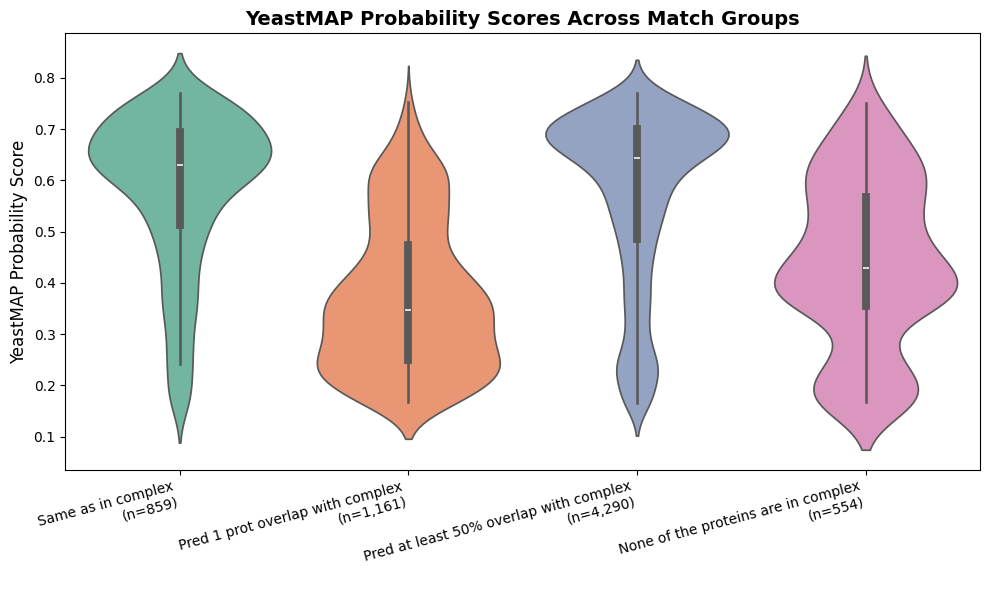

In [20]:
# 1. Label rows into Groups A, B, and C using Polars conditional logic
complex_pairs_with_scores_filtered = complex_pairs_with_scores.filter(pl.col("size_pred")< 30)
grouped_df = complex_pairs_with_scores_filtered.with_columns(
    pl.when(pl.col("exact_size_match") == True)
    .then(pl.lit("Same as in complex"))

    .when((pl.col("exact_size_match") == False) & (pl.col("match_count") == 1))
    .then(pl.lit("Pred 1 prot overlap with complex"))
    
    .when((pl.col("exact_size_match") == False) & (pl.col("jaccard_similarity") >= 0.5))
    .then(pl.lit("Pred at least 50% overlap with complex"))
    
    .when(pl.col("match_count") == 0)
    .then(pl.lit("None of the proteins are in complex"))
    
    .otherwise(pl.lit(None))
    .alias("Match Category")
).filter(pl.col("Match Category").is_not_null())

counts = grouped_df.group_by("Match Category").len()
counts_dict = dict(zip(counts["Match Category"], counts["len"]))

order = [
    "Same as in complex",
    "Pred 1 prot overlap with complex",
    "Pred at least 50% overlap with complex",
    "None of the proteins are in complex",
]
labels_with_n = [f"{cat}\n(n={counts_dict.get(cat, 0):,})" for cat in order]

plt.figure(figsize=(10, 6))
ax = sns.violinplot(
    data=grouped_df.to_pandas(),
    x="Match Category",
    y="probability_score",
    order=order,
    palette="Set2",
)
ax.set_xticklabels(labels_with_n)

plt.title(
    "YeastMAP Probability Scores Across Match Groups",
    fontsize=14,
    fontweight="bold",
)
plt.ylabel("YeastMAP Probability Score", fontsize=12)
plt.xlabel("")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
# #which complexes are those where overlap only 1 and why is the proababilty scoer so los
# what ahppens if i take out very large compelxes? what are realistic sizes

complex_pairs_overlap_1 = complex_pairs_with_scores.filter((pl.col("exact_size_match") == False) & (pl.col("match_count") == 1))

In [ ]:
import pandas as pd
complex_pairs_with_scores = complex_pairs_with_scores.with_columns(
    pair_on_complex_db=(
        pl.col("true_complex").str.split(" ").list.contains(pl.col("protein_A"))
        & pl.col("true_complex").str.split(" ").list.contains(pl.col("protein_B"))
    ).fill_null(False),
    predicted_known_percentage=(pl.col("match_count") / pl.col("size_pred")).round(2)
)

fig, axes = plt.subplots(1, 4, figsize=(20, 4), sharey=True)
sizes = [2, 3, 4, 5]
palette_colors = {True: "green", False: "darkred"}

for i, (ax, size) in enumerate(zip(axes, sizes)):
    subset = complex_pairs_with_scores.filter(
        pl.col("size_pred") == size
    ).to_pandas()

    n_complexes = subset["predicted_complex_id"].nunique()
    expected_order = [round(match / size, 2) for match in range(0, size + 1)]

    # ensure both hue values exist for every x-category so split violins are always centered on the tick
    dummy_rows = []
    for xval in expected_order:
        for hue_val in [False, True]:
            if not ((subset["predicted_known_percentage"] == xval) & 
                    (subset["pair_on_complex_db"] == hue_val)).any():
                dummy_rows.append({
                    "predicted_known_percentage": xval,
                    "pair_on_complex_db": hue_val,
                    "probability_score": float("nan"),
                })
    if dummy_rows:
        subset = pd.concat([subset, pd.DataFrame(dummy_rows)], ignore_index=True)

    sns.violinplot(
        data=subset,
        x="predicted_known_percentage",
        y="probability_score",
        hue="pair_on_complex_db",
        split=True,
        hue_order=[False, True],
        order=expected_order,
        palette=palette_colors,
        inner="quartile",
        ax=ax,
        legend=(i == 3),
        density_norm="width",
    )

    ax.set_title(f"Complex Size: {size}\n(n={n_complexes} complexes)", fontsize=12)
    ax.set_xlabel("Overlap with COMPLEX / predicted complex size", fontsize=9 )
    ax.set_ylabel("Pairwise Probability Score", fontsize= 10)
    ax.grid(True, linestyle="--", alpha=0.5)
leg = axes[3].get_legend()
axes[3].legend_.remove()
axes[0].legend(handles=leg.legend_handles, labels=[t.get_text() for t in leg.get_texts()], title="Pair on Complex", loc="lower left")

plt.show()

In [ ]:
rows_false, rows_true = [], []
for size in sizes:
    subset = complex_pairs_with_scores.filter(pl.col("size_pred") == size).to_pandas()
    expected_order = [round(match / size, 2) for match in range(0, size + 1)]
    row_f, row_t = [f"Size {size}"], [f"Size {size}"]
    for xval in expected_order:
        n_false = ((subset["predicted_known_percentage"] == xval) & (subset["pair_on_complex_db"] == False)).sum()
        n_true  = ((subset["predicted_known_percentage"] == xval) & (subset["pair_on_complex_db"] == True)).sum()
        row_f.append(str(n_false))
        row_t.append(str(n_true))
    rows_false.append(row_f)
    rows_true.append(row_t)

# Build combined rows: for each size, one red row then one green row
max_cols = max(len(r) for r in rows_false)  # size + n_overlaps
col_labels = [""] + [f"{round(m/s,2)}" for s in [sizes[-1]] for m in range(0, s+1)]  # placeholder, overridden per size

fig, axes = plt.subplots(1, len(sizes), figsize=(12, 2.5),
                         gridspec_kw={"width_ratios": [s + 1 for s in sizes]})
for ax in axes:
    ax.axis("off")

for i, size in enumerate(sizes):
    ax = axes[i]
    expected_order = [round(match / size, 2) for match in range(0, size + 1)]
    col_labels = [""] + [str(x) for x in expected_order]

    cell_text  = [rows_false[i][1:], rows_true[i][1:]]  # drop the "Size X" label
    row_labels = ["not on DB", "on DB"]
    cell_colors = [
        ["#ffe5e5"] * len(expected_order),
        ["#e5f5e5"] * len(expected_order),
    ]
    row_label_colors = [["#c0392b"], ["#27ae60"]]

    table = ax.table(
        cellText=cell_text,
        rowLabels=row_labels,
        colLabels=expected_order,
        cellLoc="center",
        loc="center",
        cellColours=cell_colors,
        rowColours=["#c0392b", "#27ae60"],
    )
    table.auto_set_column_width(list(range(len(expected_order))))
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 1.6)

    # Header styling
    for j in range(len(expected_order)):
        table[0, j].set_facecolor("#2c2c2c")
        table[0, j].set_text_props(color="white", fontweight="bold")

    # Row label text color white
    for r in [1, 2]:
        table[r, -1].set_text_props(color="white", fontweight="bold")

    ax.set_title(f"Complex Size: {size}\n(n={complex_pairs_with_scores.filter(pl.col('size_pred')==size).to_pandas()['predicted_complex_id'].nunique()} complexes)", fontsize=10)

fig.suptitle("Datapoints per violin half ", fontsize=12)
plt.tight_layout()
#plt.savefig("violin_counts_table.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
counts = complex_pairs_with_scores.group_by("pair_on_complex_db").len()

n_false = counts.filter(pl.col("pair_on_complex_db") == False).select("len").item() if False in counts["pair_on_complex_db"] else 0
n_true = counts.filter(pl.col("pair_on_complex_db") == True).select("len").item() if True in counts["pair_on_complex_db"] else 0

# 2. Add dummy column and convert to Pandas
df_for_plot = complex_pairs_with_scores.with_columns(
    pl.lit("All Data").alias("group")
).to_pandas()

plt.figure(figsize=(6, 6))


ax = sns.violinplot(
    data=df_for_plot, 
    x="group",                 
    y="probability_score", 
    hue="pair_on_complex_db", 
    split=True,
    hue_order=[False, True],
    palette={True: "green", False: "darkred"},
    inner="quartile"
)

legend_labels = [f"False (n = {n_false:,})", f"True (n = {n_true:,})"]


handles, _ = ax.get_legend_handles_labels()
ax.legend(handles=handles, labels=legend_labels, title="Pair on Complex", loc="upper left")

plt.title("YeastMAP Pairwise Probability Scores")
plt.xlabel("") 
plt.ylabel("YeastMAP Probability Score")


plt.tight_layout()
plt.show()

In [ ]:

# for complexes where size pred is bigger that from complex on db is the pred score for those added proteins lower
yeastmap_complex_pairs_with_scores = pl.read_csv("./Dataframes/Yeast_Map/yeastmap_complex_pairs_with_scores_incl_db.csv")


additional_prot_YM = yeastmap_complex_pairs_with_scores.filter(pl.col("size_true")>pl.col("size_pred"))
counts_add = additional_prot_YM.group_by("pair_on_complex_db").len()

n_on_db = counts_add.filter(pl.col("pair_on_complex_db") == True).select("len").item() if True in counts_add["pair_on_complex_db"] else 0
n_not_on_db = counts_add.filter(pl.col("pair_on_complex_db") == False).select("len").item() if False in counts_add["pair_on_complex_db"] else 0

# 2. Add dummy column and convert to Pandas
df_for_add_plot = additional_prot_YM.with_columns(
    pl.lit("All Data").alias("group")
).to_pandas()

plt.figure(figsize=(6, 6))


ax = sns.violinplot(
    data=df_for_add_plot, 
    x="group",                 
    y="probability_score", 
    hue="pair_on_complex_db", 
    split=True,
    hue_order=[False, True],
    palette={True: "green", False: "darkred"},
    inner="quartile"
)

legend_labels = [f"Not on Complex DB (n = {n_not_on_db:,})", f"On Complex DB (n = {n_on_db:,})"]

handles, _ = ax.get_legend_handles_labels()
ax.legend(handles=handles, labels=legend_labels, title = f"Amount of Complexes {len(additional_prot_YM['predicted_complex_id'].unique())}", loc="lower left")

plt.title("Pairwise Probability Scores based on whether the additional protein is already in the complex DB or not")
plt.xlabel("") 
plt.ylabel("YeastMAP Probability Score")


plt.tight_layout()
plt.show()


In [ ]:
#do proeints with a diff confidence complec score also have a diff pair value

counts = yeastmap_complex_pairs_with_scores.group_by("ComplexConfidence").len()

n_2 = counts.filter(pl.col("ComplexConfidence") == 2).select("len").item() if 2 in counts["ComplexConfidence"] else 0
n_1 = counts.filter(pl.col("ComplexConfidence") == 1).select("len").item() if 1 in counts["ComplexConfidence"] else 0

# 2. Add dummy column and convert to Pandas
df_for_conf_plot = yeastmap_complex_pairs_with_scores.with_columns(
    pl.lit("All Data").alias("group")
).to_pandas()

plt.figure(figsize=(6, 6))


ax = sns.violinplot(
    data=df_for_conf_plot, 
    x="group",                 
    y="probability_score", 
    hue="ComplexConfidence", 
    split=True,
    hue_order=[1, 2],
    palette={2: "indianred", 1: "royalblue"},
    inner="quartile"
)

legend_labels = [f"Confidence 1=Extremely High (n = {n_1:,}) - 168 Complexes", f"Confidence 2=Very High           (n = {n_2:,}) - 611 Complexes"]

handles, _ = ax.get_legend_handles_labels()
ax.legend(handles=handles, labels=legend_labels, loc="lower left")

plt.title("YeastMAP Pairwise Probability Scores based on Complex confidence")
plt.xlabel("") 
plt.ylabel("YeastMAP Probability Score")


plt.tight_layout()
plt.show()

## check wheterh pair is on intact and how those scores are different

In [2]:
yeastmap_complex_pairs_with_scores = pl.read_csv("./Dataframes/Yeast_Map/yeastmap_complex_pairs_with_scores_incl_db.csv")
IntAct_yeast_proteins_uni_prot = pl.read_csv("./Dataframes/Yeast_Map/IntAct_yeast_proteins_uni_prot.csv")

ym = yeastmap_complex_pairs_with_scores.with_columns([
    pl.min_horizontal("protein_A", "protein_B").alias("p1"),
    pl.max_horizontal("protein_A", "protein_B").alias("p2"),
])

# 2. Canonicalize IntAct pairs + add marker
intact = (
    IntAct_yeast_proteins_uni_prot
    .with_columns([
        pl.min_horizontal("#ID(s) interactor A", "ID(s) interactor B").alias("p1"),
        pl.max_horizontal("#ID(s) interactor A", "ID(s) interactor B").alias("p2"),
    ])
    .select(["p1", "p2"])
    .unique()
    .with_columns(pl.lit(True).alias("_on_intact"))
)

# 3. Left join + boolean flag
ym_with_intact = (
    ym
    .join(intact, on=["p1", "p2"], how="left")
    .with_columns(
        pl.col("_on_intact").fill_null(False).alias("pair_on_intact")
    )
    .drop(["p1", "p2", "_on_intact"])
)

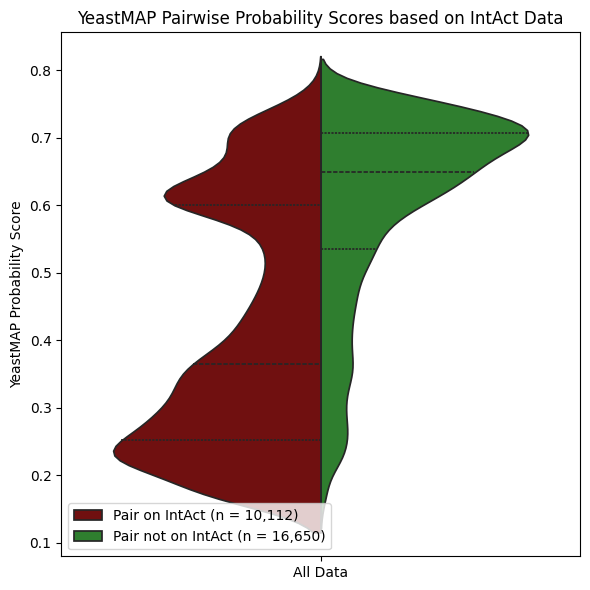

In [10]:
counts_intact = ym_with_intact.group_by("pair_on_intact").len()

n_true_intact = counts_intact.filter(pl.col("pair_on_intact") == True).select("len").item() if True in counts_intact["pair_on_intact"] else 0
n_false_intact = counts_intact.filter(pl.col("pair_on_intact") == False).select("len").item() if False in counts_intact["pair_on_intact"] else 0

# 2. Add dummy column and convert to Pandas
df_for_intact_plot = ym_with_intact.with_columns(
    pl.lit("All Data").alias("group")
).to_pandas()

plt.figure(figsize=(6, 6))


ax = sns.violinplot(
    data=df_for_intact_plot, 
    x="group",                 
    y="probability_score", 
    hue="pair_on_intact", 
    split=True,
    hue_order=[False, True],
    palette={False: "maroon", True: "forestgreen"},
    inner="quartile"
)

legend_labels = [f"Pair on IntAct (n = {n_true_intact:,})", f"Pair not on IntAct (n = {n_false_intact:,})"]

handles, _ = ax.get_legend_handles_labels()
ax.legend(handles=handles, labels=legend_labels, loc="lower left")

plt.title("YeastMAP Pairwise Probability Scores based on IntAct Data")
plt.xlabel("") 
plt.ylabel("YeastMAP Probability Score")


plt.tight_layout()
plt.show()

##  At which probability score does the complex falls apart

how many complexes from COMPLEX are completely recovered

In [5]:
#how many of the complex complexes are also in yeast map (exactly as tehy are on the db)
print(len(yeastmap_complex_pairs_with_scores_incl_db.filter((pl.col("exact_size_match") == False)&(pl.col("match_count") >= 2)).select("#Complex ac").unique())) #Partial overlap (at least two, not all)
'''
prior one not furtehr distinguishable, as some complexes are recovered both from bigger and smaller predicted complexes
n_pred_larger  = yeastmap_complex_pairs_with_scores_incl_db.filter((~pl.col("exact_size_match")) & (pl.col("match_count") >= 2) & (pl.col("size_true") < pl.col("size_pred"))).select("#Complex ac").unique().height
n_pred_smaller = yeastmap_complex_pairs_with_scores_incl_db.filter((~pl.col("exact_size_match")) & (pl.col("match_count") >= 2) & (pl.col("size_true") > pl.col("size_pred"))).select("#Complex ac").unique().height

print(len(yeastmap_complex_pairs_with_scores_incl_db.filter((pl.col("match_count") >= 2)).select("#Complex ac").unique())) #Partial overlap (at least two, not all)
'''

print(len(yeastmap_complex_pairs_with_scores_incl_db.filter(pl.col("jaccard_similarity") == 1.0).select("#Complex ac").unique())) #Recovered exactly as on COMPLEX 

215
117


In [3]:
yeastmap_complex_pairs_with_scores_incl_db = pl.read_csv("./Dataframes/Yeast_Map/yeastmap_complex_pairs_with_scores_incl_db.csv")

complex_pairs_with_scores_unique_score = yeastmap_complex_pairs_with_scores_incl_db.sort("jaccard_similarity", descending=True).unique(subset = "predicted_complex_id", keep = "first")

edges_forward = yeastmap_complex_pairs_with_scores_incl_db.select(
    pl.col("predicted_complex_id"),
    pl.col("size_pred"),                 
    pl.col("protein_A").alias("protein"),
    pl.col("probability_score"),
    pl.col("predicted_complex"),
    pl.col("exact_size_match"),
    pl.col("match_count"),
    pl.col("jaccard_similarity")
)

edges_backward = yeastmap_complex_pairs_with_scores_incl_db.select(
    pl.col("predicted_complex_id"),
    pl.col("size_pred"),                  
    pl.col("protein_B").alias("protein"),
    pl.col("probability_score"),
    pl.col("predicted_complex"),
    pl.col("exact_size_match"),
    pl.col("match_count"),
    pl.col("jaccard_similarity")
)


all_edges = pl.concat([edges_forward, edges_backward])


metadata_cols = [
    "predicted_complex_id", "size_pred", "predicted_complex", 
    "exact_size_match", "match_count", "jaccard_similarity"
]


protein_strongest_links = all_edges.group_by(metadata_cols + ["protein"]).agg(
    pl.col("probability_score").max().alias("max_score")
)

complex_breaking_values = protein_strongest_links.group_by(metadata_cols).agg(
    pl.col("max_score").min().alias("breaking_value"), 
    pl.count("protein").alias("complex_size") 
).sort("breaking_value")

print(complex_breaking_values.head(3))

shape: (3, 8)
┌────────────┬───────────┬────────────┬────────────┬───────────┬───────────┬───────────┬───────────┐
│ predicted_ ┆ size_pred ┆ predicted_ ┆ exact_size ┆ match_cou ┆ jaccard_s ┆ breaking_ ┆ complex_s │
│ complex_id ┆ ---       ┆ complex    ┆ _match     ┆ nt        ┆ imilarity ┆ value     ┆ ize       │
│ ---        ┆ i64       ┆ ---        ┆ ---        ┆ ---       ┆ ---       ┆ ---       ┆ ---       │
│ str        ┆           ┆ str        ┆ bool       ┆ i64       ┆ f64       ┆ f64       ┆ u32       │
╞════════════╪═══════════╪════════════╪════════════╪═══════════╪═══════════╪═══════════╪═══════════╡
│ CPX_394    ┆ 3         ┆ P38745     ┆ false      ┆ 0         ┆ 0.0       ┆ 0.350764  ┆ 3         │
│            ┆           ┆ P09620     ┆            ┆           ┆           ┆           ┆           │
│            ┆           ┆ P32906     ┆            ┆           ┆           ┆           ┆           │
│ CPX_561    ┆ 4         ┆ P38745     ┆ false      ┆ 1         ┆ 0.2       ┆ 

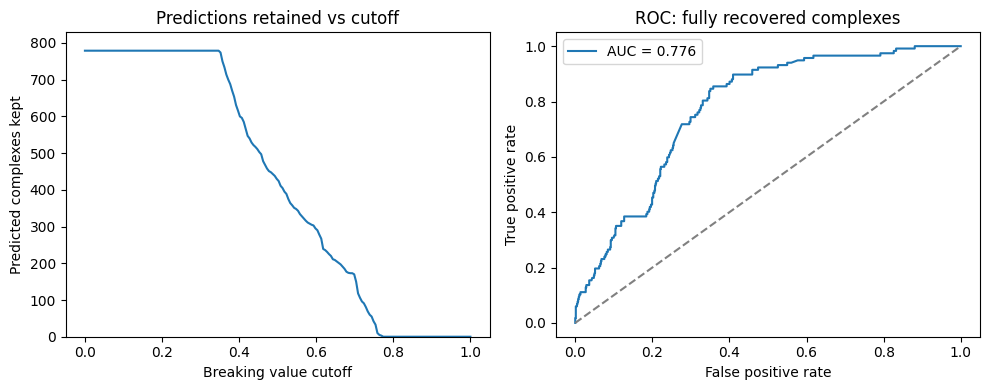

In [10]:
import numpy as np
from sklearn.metrics import roc_curve, auc

complex_breaking_values = complex_breaking_values.with_columns((pl.col("jaccard_similarity") == 1.0).alias("fully_recovered"))


total_complexes = complex_breaking_values.select("predicted_complex_id").n_unique()


# 2. LEFT PANEL: complexes kept vs cutoff
cutoffs = np.linspace(0, 1, 200)

kept_counts = [
    complex_breaking_values.filter(pl.col("breaking_value") >= c)
      .select("predicted_complex_id")
      .n_unique()
    for c in cutoffs
]

# 3. RIGHT PANEL: ROC curve

# Convert to numpy for sklearn
y_true = complex_breaking_values.select("fully_recovered").to_numpy().ravel().astype(int)
y_score = complex_breaking_values.select("breaking_value").to_numpy().ravel()

fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)


plt.figure(figsize=(10, 4))


plt.subplot(1, 2, 1)
plt.plot(cutoffs, kept_counts)
plt.xlabel("Breaking value cutoff")
plt.ylabel("Predicted complexes kept")
plt.title("Predictions retained vs cutoff")
plt.ylim(0, total_complexes+50)


plt.subplot(1, 2, 2)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", color= "grey")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC: fully recovered complexes")
plt.legend()

plt.tight_layout()
plt.show()

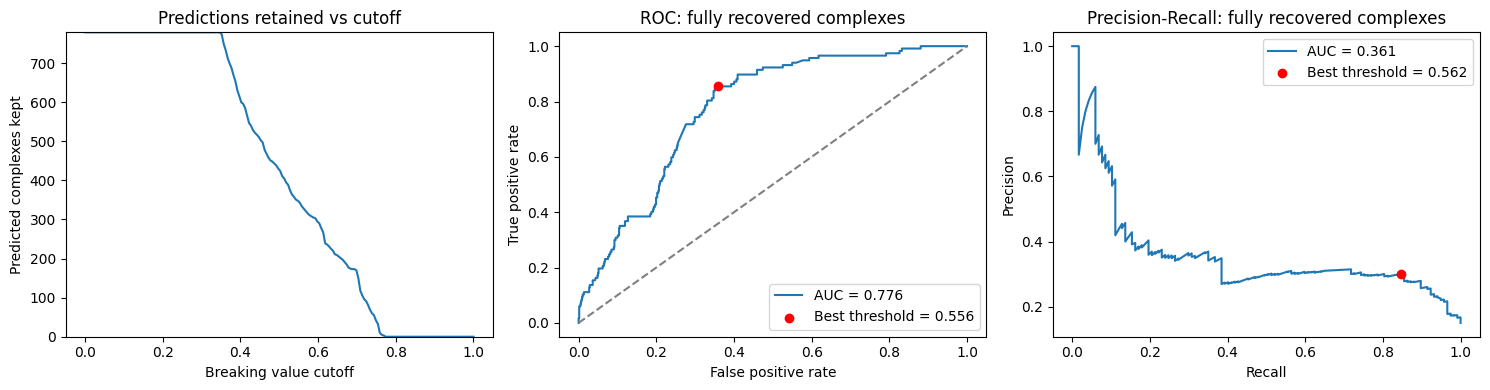

Best threshold (Youden's J, ROC):   0.5558
Best threshold (max F1, PR curve):  0.5616


In [4]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve

# ------------------------------------------------------------
# 1. Prepare data
# ------------------------------------------------------------

df = complex_breaking_values.with_columns(
    (pl.col("jaccard_similarity") == 1.0).alias("fully_recovered")
)

total_complexes = df.select("predicted_complex_id").n_unique()

# ------------------------------------------------------------
# 2. LEFT PANEL: complexes kept vs cutoff
# ------------------------------------------------------------

cutoffs = np.linspace(0, 1, 200)

kept_counts = [
    df.filter(pl.col("breaking_value") >= c)
      .select("predicted_complex_id")
      .n_unique()
    for c in cutoffs
]

# ------------------------------------------------------------
# 3. ROC curve + best threshold (Youden's J)
# ------------------------------------------------------------

y_true = df.select("fully_recovered").to_numpy().ravel().astype(int)
y_score = df.select("breaking_value").to_numpy().ravel()

fpr, tpr, roc_thresholds = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

youden_j = tpr - fpr
best_roc_idx = np.argmax(youden_j)
best_roc_threshold = roc_thresholds[best_roc_idx]

# ------------------------------------------------------------
# 4. Precision-Recall curve + best threshold (max F1)
# ------------------------------------------------------------

precision, recall, pr_thresholds = precision_recall_curve(y_true, y_score)
pr_auc = auc(recall, precision)

# precision/recall have one more element than pr_thresholds,
# so trim the last point when computing F1 per threshold
f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-12)
best_pr_idx = np.argmax(f1_scores)
best_pr_threshold = pr_thresholds[best_pr_idx]

# ------------------------------------------------------------
# 5. Plot
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# --- Left subplot ---
axes[0].plot(cutoffs, kept_counts)
axes[0].set_xlabel("Breaking value cutoff")
axes[0].set_ylabel("Predicted complexes kept")
axes[0].set_title("Predictions retained vs cutoff")
axes[0].set_ylim(0, total_complexes)

# --- Middle subplot (ROC) ---
axes[1].plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1].scatter(fpr[best_roc_idx], tpr[best_roc_idx], color="red", zorder=5,
                label=f"Best threshold = {best_roc_threshold:.3f}")
axes[1].set_xlabel("False positive rate")
axes[1].set_ylabel("True positive rate")
axes[1].set_title("ROC: fully recovered complexes")
axes[1].legend()

# --- Right subplot (Precision-Recall) ---
axes[2].plot(recall, precision, label=f"AUC = {pr_auc:.3f}")
axes[2].scatter(recall[best_pr_idx], precision[best_pr_idx], color="red", zorder=5,
                label=f"Best threshold = {best_pr_threshold:.3f}")
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].set_title("Precision-Recall: fully recovered complexes")
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"Best threshold (Youden's J, ROC):   {best_roc_threshold:.4f}")
print(f"Best threshold (max F1, PR curve):  {best_pr_threshold:.4f}")


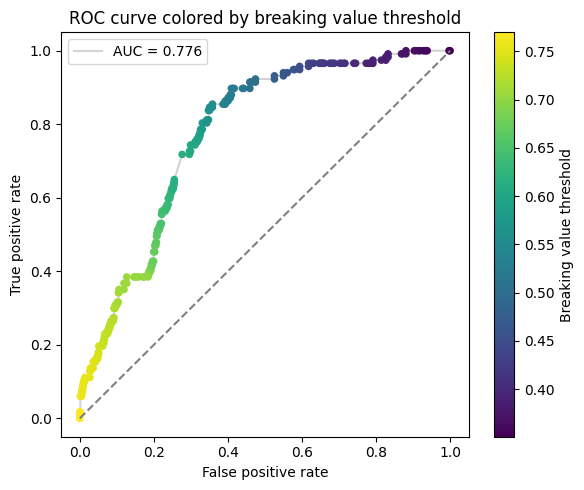

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, auc

y_true = df.select("fully_recovered").to_numpy().ravel().astype(int)
y_score = df.select("breaking_value").to_numpy().ravel()

fpr, tpr, roc_thresholds = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

# sklearn sets the first threshold to inf (or max+1) so the curve starts at (0,0)
# replace it with the actual max score so it's plottable on the colorbar
roc_thresholds_plot = roc_thresholds.copy()
roc_thresholds_plot[~np.isfinite(roc_thresholds_plot)] = y_score.max()

fig, ax = plt.subplots(figsize=(6, 5))

ax.plot(fpr, tpr, color="lightgray", zorder=0, label=f"AUC = {roc_auc:.3f}")
sc = ax.scatter(fpr, tpr, c=roc_thresholds_plot, cmap="viridis", s=20, zorder=1)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray")

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Breaking value threshold")

ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("ROC curve colored by breaking value threshold")
ax.legend()

plt.tight_layout()
plt.show()